# Day 4-04｜骨架與球軌跡整合視覺化
> Python 籃球運動資料分析課程  
> 結合 Day 4-03 的人體骨架與球追蹤結果，把投籃動作與球的位置一起疊回影片。  
> 修課背景：具備基礎 Python 語法即可；不預設電腦視覺或運動資料分析經驗。

## 學習目標
- 把姿態資料和球追蹤資料對齊到同一支影片。
- 產生球中心點 CSV、球軌跡圖與整合 overlay 預覽。
- 讓初學者能直接把「姿態變化」和「球飛行」對回原始動作。

## 完成產出
- `assets/results/d4_04_ball_track.csv`
- `assets/results/d4_04_ball_path.png`
- `assets/results/d4_04_ball_overlay_preview.mp4`

## 課堂要求
- 請先完成 Day 4-03 的姿態分析。
- 請先確認 `assets/converted/` 內至少有一支 mp4。
- 如果 Day 4-02 的 tracking preview json 已存在，這個單元會直接沿用；否則會自動重跑一次追蹤。


## 執行階段提醒
如果你是在 Google Colab 操作，請同學優先選擇 **T4 GPU**。  
這個單元會把骨架、球的位置、release frame 與右側骨架 panel 疊在同一支影片上，執行時間通常會比單純畫圖更長。


## 課程流程
1. 載入 Day 4-03 的姿態結果。
2. 優先沿用 Day 4-02 產生的 tracking json；若不存在就重跑一次 detector + ByteTrack。
3. 轉成 ball center CSV 與球軌跡圖。
4. 把骨架與球的位置整合回原影片。


In [1]:
from pathlib import Path
import subprocess
import sys

COURSE_ROOT_HINT = next(
    (p for p in [Path.cwd().resolve(), *Path.cwd().resolve().parents] if (p / "src" / "course_setup.py").exists()),
    Path("/content/basketball_hackathon/course"),
)
if not (COURSE_ROOT_HINT / "src" / "course_setup.py").exists() and "google.colab" in sys.modules:
    COURSE_ROOT_HINT.parent.mkdir(parents=True, exist_ok=True)
    subprocess.run([
        "git", "clone", "--depth", "1", "https://github.com/henry753951/basketball-hackathon-course.git", str(COURSE_ROOT_HINT)
    ], check=True)
if str(COURSE_ROOT_HINT) not in sys.path:
    sys.path.insert(0, str(COURSE_ROOT_HINT))

from src.course_setup import bootstrap_course_repo  # noqa: E402

COURSE_ROOT = bootstrap_course_repo(COURSE_ROOT_HINT)


課程根目錄: H:\Repos\basketball-hackathon-course
素材資料夾: H:\Repos\basketball-hackathon-course\assets
工具模組: H:\Repos\basketball-hackathon-course\src


In [2]:
import pandas as pd
from src.cv_utils import load_json
from src.plot_utils import plot_ball_path
from src.shooting_utils import estimate_release_frame, render_pose_and_ball_overlay_video
from src.video_utils import display_video_in_notebook, pick_first_converted_video
from src.yolo_utils import (
    ball_detector_model_path,
    ball_track_dataframe_from_tracking_records,
    load_yolo_model,
    write_bytetrack_preview_video,
)

RESULTS = COURSE_ROOT / "assets" / "results"
video_path = pick_first_converted_video(COURSE_ROOT)
pose_csv = RESULTS / "d4_03_pose_angles.csv"
preview_json = RESULTS / "d4_02_bytetrack_ball_preview.json"
model_path = ball_detector_model_path(COURSE_ROOT)
model = load_yolo_model(model_path)
model_names = getattr(model, "names", {}) or {}
class_names_override = [str(model_names[idx]) for idx in sorted(model_names)] if isinstance(model_names, dict) else list(model_names)
keep_class_names = [name for name in class_names_override if name.lower() == "ball"]
if not keep_class_names:
    keep_class_names = ["Ball", "ball", "basketball"]

if not pose_csv.exists():
    raise FileNotFoundError(f"找不到姿態結果：{pose_csv}。請先完成 Day 4-03。")

pose_df = pd.read_csv(pose_csv)
if pose_df.empty:
    raise RuntimeError("d4_03_pose_angles.csv 是空的，請重新執行 Day 4-03。")

print("using video:", video_path)
print("pose csv:", pose_csv)
print("preview json:", preview_json)
print("model path:", model_path)
print("model class names:", class_names_override)
print("keep class names:", keep_class_names)


using video: H:\Repos\basketball-hackathon-course\assets\converted\video_001.mp4
pose csv: H:\Repos\basketball-hackathon-course\assets\results\d4_03_pose_angles.csv
preview json: H:\Repos\basketball-hackathon-course\assets\results\d4_02_bytetrack_ball_preview.json
model path: H:\Repos\basketball-hackathon-course\assets\models\detectors\yolo26n_basketball_ball_best.pt
model class names: ['Ball', 'Red_11', 'Red_2', 'Red_23', 'Red_7', 'Red_9', 'Refree_1', 'Refree_2', 'White_14', 'White_16', 'White_2', 'White_27', 'White_34']
keep class names: ['Ball']


In [3]:
FORCE_REFRESH_TRACKING = True

if preview_json.exists() and not FORCE_REFRESH_TRACKING:
    preview_records = load_json(preview_json)
    print("沿用 Day 4-02 的 tracking json")
else:
    preview_mp4 = RESULTS / "d4_02_bytetrack_ball_preview.mp4"
    preview_mp4, preview_records = write_bytetrack_preview_video(
        video_path=video_path,
        model_path=model_path,
        output_path=preview_mp4,
        max_frames=180,
        conf=0.10,
        imgsz=960,
        class_names_override=class_names_override,
        keep_class_names=keep_class_names,
    )
    print("重新建立 Day 4-02 tracking preview:", preview_mp4)

ball_df = ball_track_dataframe_from_tracking_records(
    preview_records,
    class_names=tuple(dict.fromkeys([*keep_class_names, "ball", "Ball", "basketball"])),
)
if ball_df.empty:
    raise RuntimeError("沒有從 ByteTrack records 整理出任何球軌跡點。請先檢查 Day 4-01 / Day 4-02 的模型預覽結果。")

out_csv = RESULTS / "d4_04_ball_track.csv"
out_csv.parent.mkdir(parents=True, exist_ok=True)
ball_df.to_csv(out_csv, index=False)
print("saved:", out_csv)
ball_df.head()


$ C:\Users\henry\scoop\apps\ffmpeg-shared\8.1\bin\ffmpeg.exe -y -i H:\Repos\basketball-hackathon-course\assets\results\d4_02_bytetrack_ball_preview.mp4 -an -vcodec libx264 -pix_fmt yuv420p -movflags +faststart -preset veryfast -crf 23 H:\Repos\basketball-hackathon-course\assets\results\d4_02_bytetrack_ball_preview.notebook.mp4
重新建立 Day 4-02 tracking preview: H:\Repos\basketball-hackathon-course\assets\results\d4_02_bytetrack_ball_preview.mp4
saved: H:\Repos\basketball-hackathon-course\assets\results\d4_04_ball_track.csv


,frame,track_id,x,y,w,h,confidence,class_name,vx,vy,speed
0,0,1,58.922735,53.579628,31.966053,24.467972,0.497448,Ball,NaN,NaN,0.000000
1,1,2,1092.890320,44.793952,30.596558,29.432131,0.468627,Ball,1033.967585,-8.785676,1034.004910
2,2,1,58.856871,53.592070,31.993870,24.488590,0.475327,Ball,-1034.033449,8.798118,1034.070878
3,3,2,1092.875916,44.776673,30.719604,29.501486,0.461571,Ball,1034.019045,-8.815396,1034.056621
4,4,1,58.971724,53.477474,31.780796,24.147621,0.480544,Ball,-1033.904192,8.700801,1033.940802


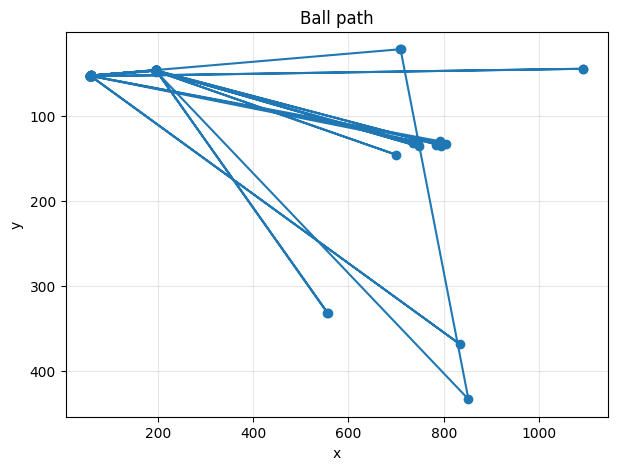

saved: H:\Repos\basketball-hackathon-course\assets\results\d4_04_ball_path.png
estimated release frame: 2


In [4]:
ball_path_png = RESULTS / "d4_04_ball_path.png"
plot_ball_path(ball_df, output_path=ball_path_png)
print("saved:", ball_path_png)

release_frame = estimate_release_frame(ball_df)
print("estimated release frame:", release_frame)


In [5]:
overlay_mp4 = RESULTS / "d4_04_ball_overlay_preview.mp4"
render_pose_and_ball_overlay_video(
    video_path,
    pose_df,
    ball_df,
    overlay_mp4,
    release_frame=release_frame,
    max_frames=180,
    trail_joint="wrist",
)
print("saved:", overlay_mp4)
display_video_in_notebook(overlay_mp4, width=820, muted=True, loop=True)


$ C:\Users\henry\scoop\apps\ffmpeg-shared\8.1\bin\ffmpeg.exe -y -i H:\Repos\basketball-hackathon-course\assets\results\d4_04_ball_overlay_preview.mp4 -an -vcodec libx264 -pix_fmt yuv420p -movflags +faststart -preset veryfast -crf 23 H:\Repos\basketball-hackathon-course\assets\results\d4_04_ball_overlay_preview.notebook.mp4
saved: H:\Repos\basketball-hackathon-course\assets\results\d4_04_ball_overlay_preview.mp4


## 本單元產出檔案

- `assets/results/d4_04_ball_track.csv`：由 detector + ByteTrack 整理出的球中心點資料。
- `assets/results/d4_04_ball_path.png`：球軌跡圖。
- `assets/results/d4_04_ball_overlay_preview.mp4`：把骨架、球位置、release frame 與右側骨架 panel 疊回原影片的預覽。
